<div style="text-align: center;" > <h1 style="margin-top: 0.2em; margin-bottom: 0.1em;">Machine Learning in Python</h1> <p style="margin-top: 0; font-style: italic;">Classification and Clustering</p> </div>

## __Structure__  
1. Introduction  
 1.1 What is Machine Learning?  
 1.2 Types of Machine Learning  
 1.3 Why Python for ML  
2. Getting Started  
 2.1 Installing Required Packages  
 2.2 Importing Libraries  
3. Data Preparation  
 3.1 Loading a Dataset  
 3.2 Exploratory Data Analysis (EDA)  
 3.3 Data Cleaning & Preprocessing  
4. Supervised Learning   
 4.1 Naive Bayes Classifier   
 4.2 Decision Tree Classifier   
 4.3 Support Vector Machines   
5. Unsupervised Learning  
 5.1 Clustering with K-Means  
 5.2 DBSCAN 
6. Interactive Tutorial Part

## 1. Introduction
### 1.1 What is Machine Learning?
Machine Learning (ML) is a set of methods that enable computers to learn patterns from data and make predictions or decisions without being explicitly programmed for each specific task.

### 1.2 Types of Machine Learning
- **Supervised Learning**: learn from labeled examples (classification, regression)
- **Unsupervised Learning**: discover structure without labels (clustering, dimensionality reduction)
- **Reinforcement Learning**: learn by interacting with an environment via rewards (we won't deal with that here)

## 2. Getting Started

Before we begin, ensure you have the required packages installed.

In [ ]:
# uncomment & run if needed
# !pip install scikit-learn pandas numpy matplotlib

Now import the libraries we will use throughout the notebook.
Most of the packages are loaded from the Scikit-learn library - one of the most popular open-source Python libraries for machine learning and data analysis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

np.random.seed(123)

## 3. Data Preparation

### 3.1 Loading a Dataset
We'll use once again the Titanic dataset from seaborn, a well-known dataset for classification that we already explored in the Dashboards tutorial. It contains passenger information such as age, class, and sex, along with whether they survived the disaster or not.

In [3]:
titanic = sns.load_dataset("titanic")
titanic = titanic.dropna(subset=["pclass","sex","age","fare","survived"])

X = titanic[["pclass", "sex", "age", "fare"]]
y = titanic["survived"]

X.head()

,pclass,sex,age,fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


### 3.2 Exploratory Data Analysis
Let's take a quick look at basic statistics. It seems like Jack and Rose were quite average passengers...

In [4]:
X.describe()

,pclass,age,fare
count,714.000000,714.000000,714.000000
mean,2.236695,29.699118,34.694514
std,0.838250,14.526497,52.918930
min,1.000000,0.420000,0.000000
25%,1.000000,20.125000,8.050000
50%,2.000000,28.000000,15.741700
75%,3.000000,38.000000,33.375000
max,3.000000,80.000000,512.329200


### 3.3 Data Cleaning & Preprocessing
For many algorithms (especially margin- and distance-based ones like SVM), scaling numerical features improves performance and stability. Features measured on different scales (e.g., fare in pounds vs. age in years) would otherwise dominate distance computations and margin optimization. However, tree-based algorithms (such as Random Forests or Gradient Boosted Trees) are generally insensitive to feature scaling, since they split on thresholds rather than relying on distances or margins. For simplicity, we'll use the scaled features for these algorithms too.

On the Titanic dataset we have both numerical features (e.g., age, fare) and categorical ones (e.g., sex, class). Since we are focusing only on scaling here, we apply `StandardScaler` to the numerical columns after splitting the data into training and test sets.

This order is important because the scaler calculates statistics such as the mean and standard deviation from the training data and then uses those same values to transform both the training and test sets. If we scaled before splitting, the mean and standard deviation would be influenced by the test data, effectively leaking information about the test set into the training process. This so-called data leakage can lead to overly optimistic performance estimates and models that perform worse on truly unseen data.

In [5]:
num_cols = ["age", "fare"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

The `stratify=y` argument ensures that the class distribution in the target variable is preserved across both the training and test sets, which is especially important in cases of imbalanced datasets.

Use `fit_transform()` on the training data to both learn the scaling parameters (mean and standard deviation) and apply the transformation. For the test data, we only call `transform()` so that the test set is scaled using the parameters learned from the training set. This, once again, prevents data leakage, ensuring that no information from the test set influences the training process and that our evaluation reflects how the model would perform on truly unseen data.

In [8]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled = pd.get_dummies(X_train_scaled, columns=["sex"], drop_first=True)
X_test_scaled = pd.get_dummies(X_test_scaled, columns=["sex"], drop_first=True)

X_train_scaled.head()

,pclass,age,fare,sex_male
81,3,-0.042955,-0.493939,True
460,1,1.250321,-0.157245,True
66,2,-0.042955,-0.474192,False
408,3,-0.587492,-0.528003,True
188,3,0.705784,-0.375454,True


## 4. Supervised Learning

### 4.1 Naive Bayes Classifier

The **Naive Bayes classifier** is a family of simple, probabilistic machine learning models based on **Bayes’ theorem**.

It estimates the posterior probability of each class given a set of observed feature values.
Formally, Bayes’ theorem can be expressed as:

$P(\text{Class} \mid \text{Features}) \propto P(\text{Features} \mid \text{Class}) \cdot P(\text{Class})$

Here, P(Class) represents the prior probability of a class, while P(Features ∣ Class)is the likelihood of observing the features given that class.

The “naive” part is the assumption that all features are **conditionally independent** given the class.  
Although this assumption is rarely true in practice, it greatly simplifies the computation: the joint likelihood of a sample can be calculated as the product of the individual feature likelihoods.

**Common types in scikit-learn:**
- `GaussianNB` – for continuous features assumed to follow a Gaussian (normal) distribution.
- `MultinomialNB` – for discrete counts (e.g., word counts in text).
- `BernoulliNB` – for binary/boolean features.

In [9]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)

y_pred_nb = nb_clf.predict(X_test_scaled)

acc_nb = accuracy_score(y_test, y_pred_nb)
print('Naive Bayes Accuracy:', acc_nb)

Naive Bayes Accuracy: 0.7832167832167832


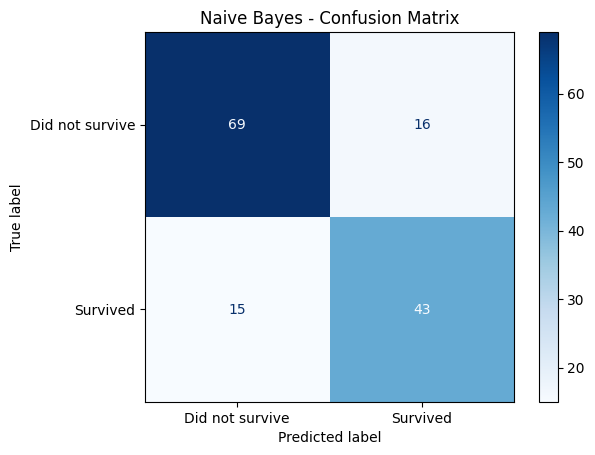

In [10]:
cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Blues")
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

### 4.2 Decision Tree Classifier

A **Decision Tree classifier** is a supervised machine learning model that predicts a target variable by learning simple decision rules from the data features.
 
- The algorithm splits the data into subsets based on the value of one feature at a time.  
- At each node, it chooses the feature and split point that best separate the classes, according to a measure like *Gini impurity* or *entropy*.  
- This process continues recursively, creating a tree structure with decision nodes and leaf nodes, where each leaf represents a class prediction.

**Common parameters in scikit-learn.** Try around with the parameters to get the best score.
- `criterion` – function to measure the quality of a split (`"gini"` or `"entropy"`).
- `max_depth` – maximum depth of the tree (controls overfitting).
- `min_samples_split` – minimum number of samples required to split a node.
- `min_samples_leaf` – minimum number of samples required to be in a leaf node.


In [16]:
dt_clf = DecisionTreeClassifier(criterion="gini", max_depth=3)
dt_clf.fit(X_train_scaled, y_train)

y_pred_dt = dt_clf.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
print('Decision Tree Accuracy:', acc_dt)

Decision Tree Accuracy: 0.8461538461538461


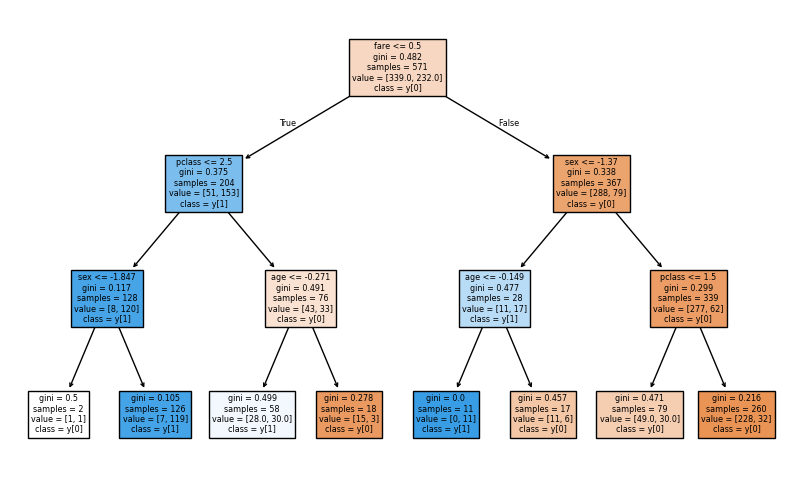

In [20]:
plt.figure(figsize=(10,6))
plot_tree(dt_clf, filled=True, feature_names=X.columns, class_names=True)
plt.show()

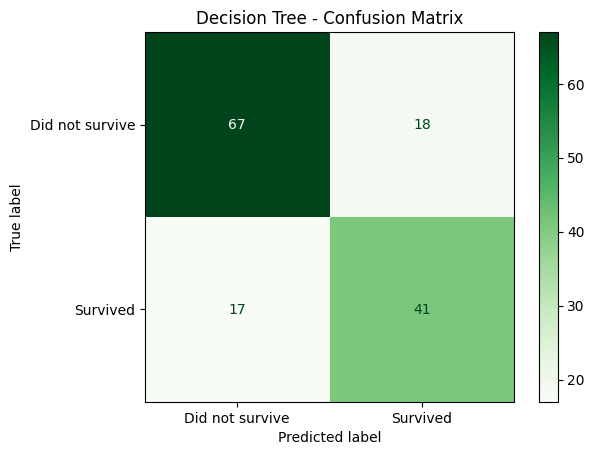

In [12]:
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

### 4.3 Support Vector Machine (SVM)

A Support Vector Machine can be used for both classification and regression, but is most commonly applied to classification tasks.
 
- SVM finds the optimal decision boundary called a **hyperplane** that separates classes in the feature space with the maximum margin.  
- The margin is the distance between the hyperplane and the nearest data points from each class, which are called **support vectors**.  
- In cases where the data is not linearly separable, SVM uses the **kernel trick** to map data into a higher-dimensional space where a separating hyperplane can be found.

**Common parameters in scikit-learn:**
- `kernel` – type of decision boundary (`"linear"`, `"poly"`, `"rbf"`, `"sigmoid"`).
- `C` – regularization parameter (trade-off between maximizing margin and minimizing classification error).
- `gamma` – kernel coefficient (controls influence of individual training samples for non-linear kernels).


In [21]:
svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

y_pred_svm = svm_clf.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
print('SVM (RBF) Accuracy:', acc_svm)

SVM (RBF) Accuracy: 0.8391608391608392


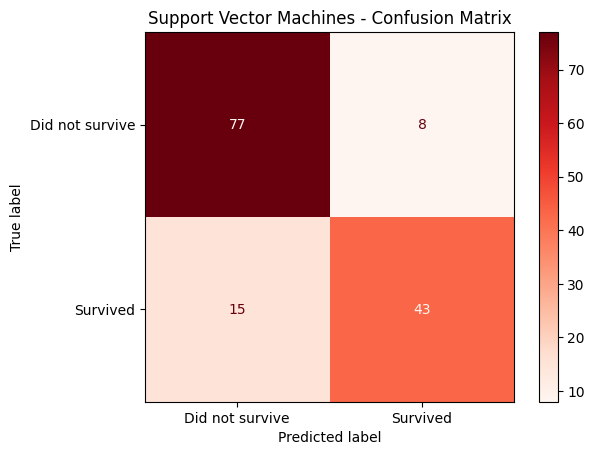

In [22]:
cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Reds")
plt.title("Support Vector Machines - Confusion Matrix")
plt.show()

## 5. Unsupervised Learning

Clustering is an unsupervised learning technique that aims to group similar data points together based on their characteristics, without relying on predefined labels. The goal is to discover hidden structures or natural groupings within the data. While classification predicts membership in predefined classes, clustering instead tries to identify those classes or patterns directly from the data.

### 5.1 Clustering with K-Means
We apply K‑Means clustering to group penguins into unlabeled clusters based on their body measurements. K‑Means partitions the data into k clusters by minimizing the within‑cluster sum of squares; here we use four numeric features and standardize them before fitting.

Try around with size k.

In [23]:
penguins = sns.load_dataset("penguins")

X = penguins[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

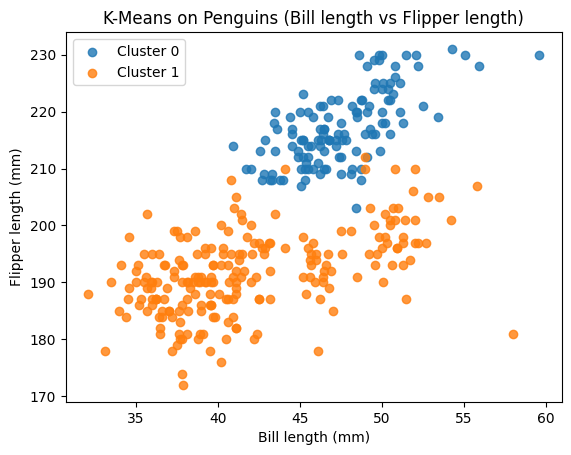

In [24]:
k = 2
kmeans = KMeans(n_clusters=k, n_init=10, random_state=123)
labels = kmeans.fit_predict(X_scaled)

plt.figure()
for c in range(k):
    mask = labels == c
    plt.scatter(X.iloc[mask, 0], X.iloc[mask, 2], label=f"Cluster {c}", alpha=0.8)  
plt.xlabel("Bill length (mm)")
plt.ylabel("Flipper length (mm)")
plt.title("K-Means on Penguins (Bill length vs Flipper length)")
plt.legend()
plt.show()

The **Silhouette Coefficient** is a metric to evaluate the quality of a clustering result.  
It measures how well each point fits within its assigned cluster compared to other clusters.

For each sample i:

- a(i) = average distance from i to all other points **in the same cluster** (intra-cluster distance).  
- b(i) = smallest average distance from i to all points **in another cluster** (nearest-cluster distance).  

The Silhouette Coefficient for that sample is:

$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$

- $s(i) \approx 1$ → the sample is well matched to its own cluster and far from others.  
- $s(i) \approx 0$ → the sample lies between clusters.  
- $s(i) < 0$ → the sample is likely in the wrong cluster.

The overall Silhouette Coefficient is the mean of s(i) over all samples.

**Interpretation:**
- Values close to **1** → well-separated, dense clusters.
- Values near **0** → overlapping clusters.
- Values negative → samples assigned to the wrong cluster.


In [25]:
# Check which k fits best
score = silhouette_score(X_scaled, labels)
print(f"Silhouette score: {score:.3f}")

Silhouette score: 0.532


### 5.2 DBSCAN

**DBSCAN** is a density-based clustering algorithm that groups together points that are closely packed in the feature space, marking points in low-density regions as **outliers**.

**Key idea:**
- Points within a certain distance ($\varepsilon$) from each other are considered neighbors.
- A point is a **core point** if it has at least a minimum number of neighbors (*min_samples*).
- Clusters are formed by connecting core points and their neighbors.
- Points that are not reachable from any cluster are labeled as noise (`-1`).

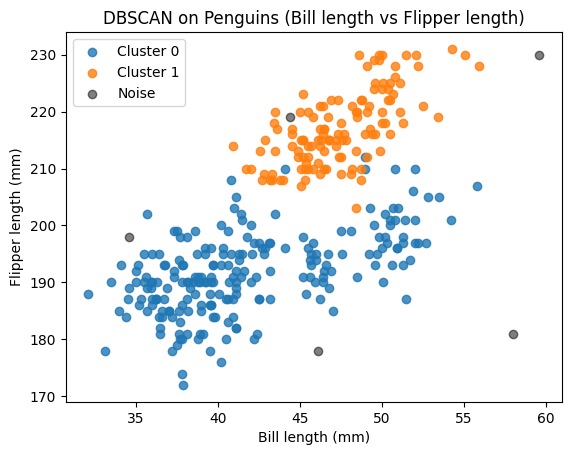

In [26]:
db = DBSCAN(eps=0.8, min_samples=5)
labels = db.fit_predict(X_scaled)

plt.figure()
for c in set(labels):
    mask = labels == c
    if c == -1:
        plt.scatter(X.iloc[mask, 0], X.iloc[mask, 2], label="Noise", alpha=0.5, c="k")
    else:
        plt.scatter(X.iloc[mask, 0], X.iloc[mask, 2], label=f"Cluster {c}", alpha=0.8)
plt.xlabel("Bill length (mm)")
plt.ylabel("Flipper length (mm)")
plt.title("DBSCAN on Penguins (Bill length vs Flipper length)")
plt.legend()
plt.show()

## 6. Interactive Tutorial Part

In this exercise, you will work with the **Wine** dataset from `scikit-learn`, which contains the chemical analysis of wines grown in the same region in Italy but derived from three different cultivars.

1. **Data Loading & Exploration**
   - Load the dataset using `from sklearn.datasets import load_wine`.
   - Make sure to also include the target class variable (i.e. the type of wine). Do this by creating a new column and the `.target`-method of `load_wine()`
   - Convert it into a Pandas DataFrame and inspect the first rows.
   - Explore basic statistics

2. **Preprocessing**
   - Identify possible features to classify the type of wine. Choose about 4-5.
   - Split the dataset into training and test sets (e.g., 80% / 20%, stratified).
   - Scale the numeric features using `Standard.Scaler()`

3. **Classification**
   - Train **at least three different classification models**, for example:
     - Naive Bayes
     - Decision Tree
     - Support Vector Machine
   - Compare their performance using **Accuracy** and a **Confusion Matrix**.
   - Interpret the results: Which model performed best? Which features seem important?

4. **Clustering**
   - Apply **K-Means** clustering on the scaled feature set:
     - Experiment with different values of `k` (e.g., 2–6) and compute the **Silhouette score**.
     - Plot the clusters for two selected features.
   - Apply **DBSCAN**:
     - Experiment with different values for `eps` and `min_samples`.
     - Identify how many clusters (and how much noise) DBSCAN finds.
   - Compare the clustering results to the true wine classes (only for evaluation, not for training).